In [43]:
import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

data_path = 'df-proc.csv'
all_df = pd.read_csv(data_path)
df = all_df[all_df.trial_type == 1].copy()
df['old_image'] = np.where(
    df.is_old_l == 1,
    df.image_l,
    df.image_r
)
df['old_value'] = np.where(
    df.is_old_l == 1,
    df.value_l,
    df.value_r
)
df['correct_old_choice'] = np.where(
    ((df.chosen_is_old==1)&(df.old_value==100))|((df.chosen_is_old==0)&(df.old_value==0)),
    1,
    0
)

In [44]:
# merge with memorability data
mem = pd.read_csv("resmem_scores.csv")
df = df.merge(mem, left_on="old_image", right_on="image_path", how="left").drop(columns="image_path")


In [54]:
df = df.rename(columns={
    'memscore': 'old_memscore', 
    'old_image':'old_object_id',
    'chosen_is_old': 'old_chosen',
    'subj id': 'subject_id'
})
old_trials = df

# 1. Are more memorable images more likely to be remembered in this task?

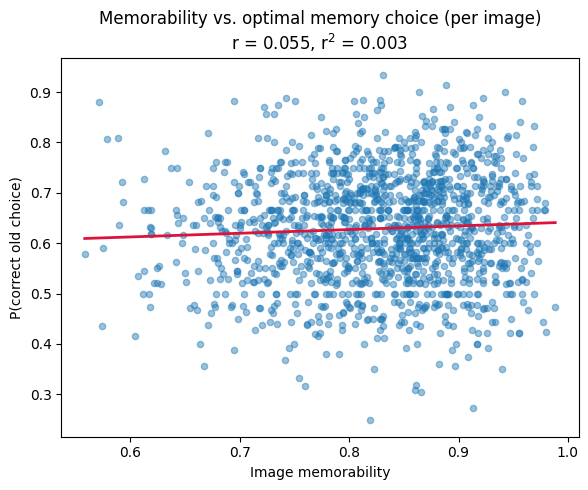

r = 0.0553
r^2 = 0.0031


In [46]:
# Average optimal old-choice performance for each object across all subjects/trials.
object_summary = (
    old_trials.groupby(['old_object_id', 'old_memscore'])['correct_old_choice']
    .mean()
    .rename('p_correct_old_choice')
    .reset_index()
)

r = object_summary['old_memscore'].corr(object_summary['p_correct_old_choice'])
r2 = r ** 2

# Plot memorability against probability of making the optimal memory-guided choice.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(object_summary['old_memscore'], object_summary['p_correct_old_choice'], alpha=0.45, s=20)

slope, intercept = np.polyfit(object_summary['old_memscore'],object_summary['p_correct_old_choice'], 1)
x = np.linspace(object_summary['old_memscore'].min(), object_summary['old_memscore'].max(), 200)
ax.plot(x, slope * x + intercept, color='crimson', linewidth=2)

ax.set_xlabel('Image memorability')
ax.set_ylabel('P(correct old choice)')
ax.set_title(f'Memorability vs. optimal memory choice (per image)\nr = {r:.3f}, r$^2$ = {r2:.3f}')
plt.tight_layout()
plt.show()

print(f'r = {r:.4f}')
print(f'r^2 = {r2:.4f}')

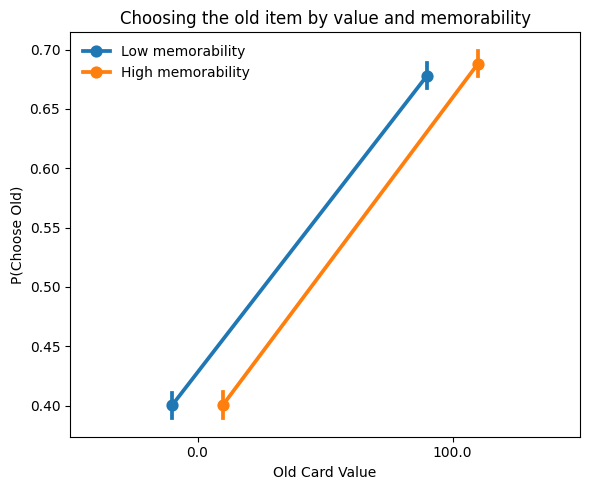

In [50]:
# Median split on old-item memorability.
median_mem = old_trials['old_memscore'].median()
old_trials['mem_group'] = np.where(
    old_trials['old_memscore'] >= median_mem,
    'High memorability',
    'Low memorability'
)

plot_df = old_trials.dropna(subset=['old_value', 'old_chosen', 'mem_group']).copy()

fig, ax = plt.subplots(figsize=(6, 5))
sns.pointplot(
    data=plot_df,
    x='old_value',
    y='old_chosen',
    hue='mem_group',
    estimator=np.mean,
    errorbar=('ci', 95),
    dodge=0.2,
    markers='o',
    linestyles='-',
    ax=ax,
)

ax.set_xlabel('Old Card Value')
ax.set_ylabel('P(Choose Old)')
ax.set_title('Choosing the old item by value and memorability')
ax.legend(frameon=False, title=None)
plt.tight_layout()
plt.show()

# 3. Is value memory reliable across subjects?

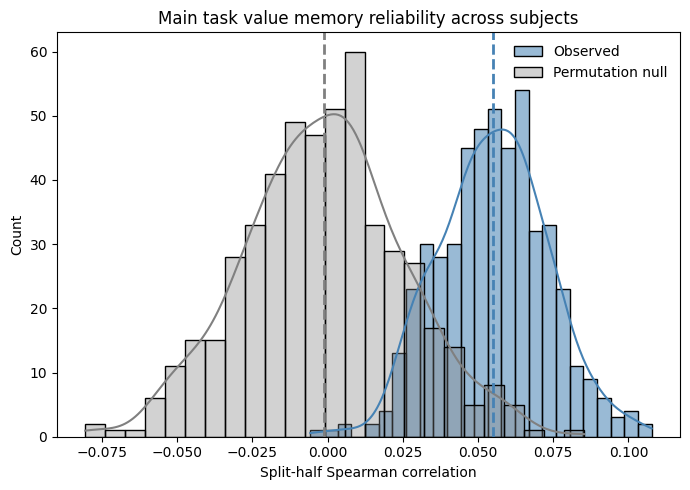

       spearman_r      null_r  spearman_brown  null_spearman_brown  \
count  500.000000  500.000000      500.000000           500.000000   
mean     0.054969   -0.001226        0.103653            -0.003847   
std      0.018089    0.026351        0.032549             0.052923   
min     -0.005763   -0.080602       -0.011593            -0.175336   
25%      0.043117   -0.018686        0.082669            -0.038084   
50%      0.055585   -0.000782        0.105316            -0.001565   
75%      0.066314    0.015639        0.124380             0.030797   
max      0.107726    0.085228        0.194499             0.157070   

         n_objects  
count   500.000000  
mean   1399.986000  
std       0.117608  
min    1399.000000  
25%    1400.000000  
50%    1400.000000  
75%    1400.000000  
max    1400.000000  
Mean observed Spearman r = 0.0550
Mean null Spearman r = -0.0012
P(observed <= 0) = 0.0020
P(observed <= null mean) = 0.0020


In [57]:
def split_half_reliability(data, subject_col, object_col, score_col, n_splits=500, seed=0):
    rng = np.random.default_rng(seed)
    subjects = np.array(sorted(data[subject_col].dropna().unique()))
    spearman_rs = []
    null_rs = []
    overlaps = []

    for _ in range(n_splits):
        shuffled = rng.permutation(subjects)
        half = len(shuffled) // 2
        split_a = shuffled[:half]
        split_b = shuffled[half:]

        mean_a = data[data[subject_col].isin(split_a)].groupby(object_col)[score_col].mean()
        mean_b = data[data[subject_col].isin(split_b)].groupby(object_col)[score_col].mean()
        merged = pd.concat([mean_a.rename('split_a'), mean_b.rename('split_b')], axis=1).dropna()

        spearman_rs.append(merged['split_a'].corr(merged['split_b'], method='spearman'))
        shuffled_b = pd.Series(rng.permutation(merged['split_b'].to_numpy()), index=merged.index)
        null_rs.append(merged['split_a'].corr(shuffled_b, method='spearman'))
        overlaps.append(len(merged))

    reliability = pd.DataFrame({'spearman_r': spearman_rs, 'null_r': null_rs, 'n_objects': overlaps})
    reliability['spearman_brown'] = 2 * reliability['spearman_r'] / (1 + reliability['spearman_r'])
    reliability['null_spearman_brown'] = 2 * reliability['null_r'] / (1 + reliability['null_r'])
    return reliability

main_reliability = split_half_reliability(
    old_trials.dropna(subset=['subject_id', 'old_object_id', 'correct_old_choice']),
    subject_col='subject_id',
    object_col='old_object_id',
    score_col='correct_old_choice',
    n_splits=500,
    seed=0,
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(main_reliability['spearman_r'], bins=25, color='steelblue', alpha=0.55, kde=True, ax=ax, label='Observed')
sns.histplot(main_reliability['null_r'], bins=25, color='gray', alpha=0.35, kde=True, ax=ax, label='Permutation null')
ax.axvline(main_reliability['spearman_r'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(main_reliability['null_r'].mean(), color='gray', linestyle='--', linewidth=2)
ax.set_xlabel('Split-half Spearman correlation')
ax.set_ylabel('Count')
ax.set_title('Main task value memory reliability across subjects')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(main_reliability[['spearman_r', 'null_r', 'spearman_brown', 'null_spearman_brown', 'n_objects']].describe())
print(f"Mean observed Spearman r = {main_reliability['spearman_r'].mean():.4f}")
print(f"Mean null Spearman r = {main_reliability['null_r'].mean():.4f}")
print(f"P(observed <= 0) = {(main_reliability['spearman_r'] <= 0).mean():.4f}")
print(f"P(observed <= null mean) = {(main_reliability['spearman_r'] <= main_reliability['null_r'].mean()).mean():.4f}")



# Extra

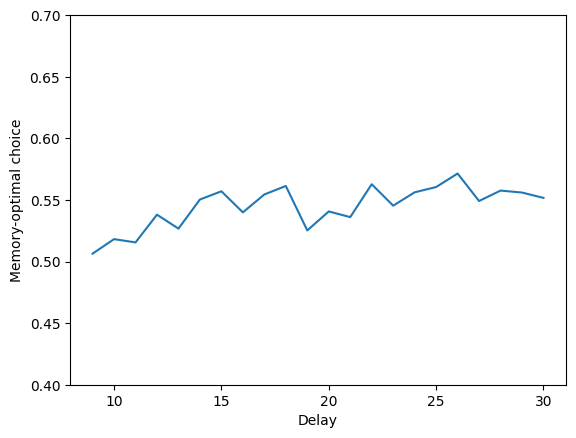

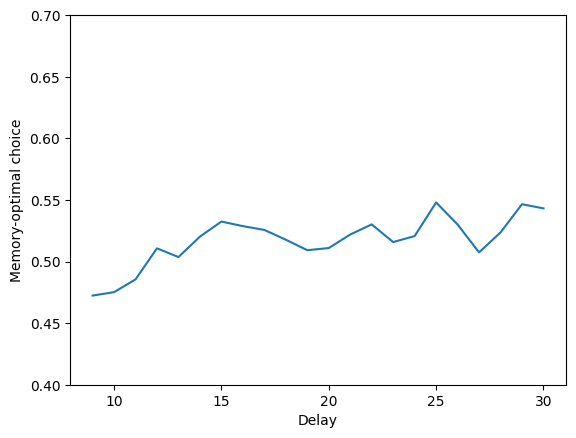

In [5]:
## effect of delay on optimal choice?
old_trials['delay'] = old_trials.trial_number - old_trials.encoding_trial
plt.plot(old_trials.groupby('delay')['correct_old_choice'].mean())
plt.xlabel('Delay')
plt.ylabel('Memory-optimal choice')
plt.ylim(0.4,0.7)
plt.show()

old_trials['delay'] = old_trials.trial_number - old_trials.encoding_trial
plt.plot(old_trials[old_trials.incongruent==1].groupby('delay')['correct_old_choice'].mean())
plt.xlabel('Delay')
plt.ylabel('Memory-optimal choice')
plt.ylim(0.4,0.7)
plt.show()